# Business Entity Resolution — Preprocessing, Visualization, Analysis & Blocking

This notebook is the interactive version of `reports/EDA_REPORT.md`. It covers:

1. **Setup & loading** — raw vs. normalized records
2. **Ground-truth structure** — cluster sizes, singletons, the one-S1-per-record constraint
3. **Noise catalogue** — what's dirty, where, and how often
4. **Preprocessing playground** — run the normalizer on any string and see every step
5. **Did cleaning help?** — similarity of true matches vs. non-matches, before/after
6. **Where the difficulty is** — name collisions, distractors, hard positives
7. **Blocking, explained** — what it is, why it's needed, worked examples, recall vs. cost
8. **A better blocker (demo)** — TF-IDF nearest-neighbour search on one state
9. **France** — the unseen test country

**Prerequisite** (once, ~12 min): from the repo root
```bash
export PYTHONPATH=code/business_entity_resolution/src
python -m ber.convert && python -m ber.preprocess --workers 32
```
Kernel: **Python (amazon-er)**.

In [1]:
import sys, json, re, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "code/business_entity_resolution/src"))
from ber.normalize import normalize_name, normalize_address, squash_phonetic
from ber.resources import load_resources

RAW, PROC = ROOT / "data/raw", ROOT / "data/processed"
RES = load_resources(PROC / "resources.json")

pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 200)

# ---- chart style: one recessive grid, thin marks, fixed categorical order ----
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
C = {"US": BLUE, "India": ORANGE, "France": AQUA}
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c2", "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "font.size": 9.5, "legend.frameon": False,
})
def bar_labels(ax, fmt="{:,.0f}", **kw):
    for c in ax.containers: ax.bar_label(c, fmt=fmt, padding=2, fontsize=8, color="#52514e", **kw)

In [2]:
# Load normalized train + test. ~12M rows each; ~1-2 min and ~15 GB RAM.
# Set SAMPLE_FRAC < 1 to load a random fraction of S2/S3 if memory is tight
# (cluster-level stats then become partial).
SAMPLE_FRAC = 1.0
COLS = ["entity_id", "business_name", "business_address", "country", "name_norm", "name_core",
        "name_legal", "name_alias", "name_domain", "name_is_translit", "name_script",
        "addr_norm", "addr_state", "addr_house", "addr_numbers"]

def load(split):
    parts = []
    for i in (1, 2, 3):
        d = pd.read_parquet(PROC / f"{split}_source{i}.parquet", columns=COLS)
        if i > 1 and SAMPLE_FRAC < 1: d = d.sample(frac=SAMPLE_FRAC, random_state=0)
        parts.append(d.assign(src=f"S{i}"))
    return pd.concat(parts, ignore_index=True).set_index("entity_id")

t0 = time.time()
tr, te = load("train"), load("test")
pairs = pd.read_parquet(PROC / "train_pairs.parquet")      # one row per true (S1, S2|S3) match
split = pd.read_parquet(PROC / "split.parquet")            # 90/10 S1 split for validation
print(f"train {len(tr):,}  test {len(te):,}  true pairs {len(pairs):,}  ({time.time()-t0:.0f}s)")
tr.sample(5, random_state=3)

train 12,527,040  test 11,702,133  true pairs 7,638,365  (116s)


,business_name,business_address,country,name_norm,name_core,name_legal,name_alias,name_domain,name_is_translit,name_script,addr_norm,addr_state,addr_house,addr_numbers,src
entity_id,,,,,,,,,,,,,,,
S3-198553653,"Bethany Bowman, Cpa, Pc Co","#558 Lost Cir, # D, Bowling Green CITY, Kentucky",US,bethany bowman cpa pc co,bethany bowman cpa,co pc,,,False,LATIN,558 lost cir d bowling green city,ky,558,558,S3
S2-457104531,"BEACON WLELHNESS VENTURES, LLC","188 LAKEVIEW FERRY LANE, CLINTON, TN",US,beacon wlelhness ventures llc,beacon wlelhness ventures,llc,,,False,LATIN,188 lakeview ferry ln clinton,tn,188,188,S2
S1-596722948,Atlas Star Private Limited,"Shop No.49, 1St Floor, Xth Central Mall, Near D-Mart, Mahavir Nagar, Kandivali (We, St...",India,atlas star private limited,atlas star,ltd pvt,,,False,LATIN,49 1st flr xth central mall nr d mart mahavir ngr kandivali we st mumbai mumbai city,mh,49,49 1,S1
S2-521756835,GRAYCE DAVIS PRECISION OCTAVE INC,"TRIVOLI, 19900 HIGS RD, PO BOX 8830, IL",US,grayce davis precision octave inc,grayce davis precision octave,inc,,,False,LATIN,trivoli 19900 higs rd 8830,il,19900,19900 8830,S2
S3-177897337,Mena Therapy [Incorporated] (ID: 67385),"Tracey St, Peabody DCP, Massachusetts",US,mena therapy incorporated id 67385,mena therapy id 67385,inc,,,False,LATIN,tracey st peabody dcp,ma,,,S3


## 1. What the data looks like

Every file has the same 4 columns: `entity_id` (prefix = source), `business_name`, `business_address`, `country`.
The ground truth lists, for each Source-1 entity, the S2/S3 records that are the same business.
Below: one real cluster. S1 is the clean reference; S2/S3 are noisy copies.

In [3]:
def show_cluster(s1_id, df=tr):
    ids = [s1_id] + pairs.loc[pairs.s1 == s1_id, "m"].tolist()
    return df.loc[ids, ["src", "business_name", "business_address", "name_norm", "addr_norm", "addr_state"]]

show_cluster("S1-706225498")   # Cabrera Secure Sciences

,src,business_name,business_address,name_norm,addr_norm,addr_state
entity_id,,,,,,
S1-706225498,S1,Cabrera Secure Sciences,"165 Barren River Drive, Unit UNIT 2, Erlanger, KY",cabrera secure sciences,165 barren river dr 2 erlanger,ky
S2-467560300,S2,Cabrera Secure Sciences Ltd,"BARREN RIVER DR, ERLANGER, KY",cabrera secure sciences ltd,barren river dr erlanger,ky
S2-906818544,S2,CABRERA SECURE SCIENCES,"ERLANGER, KY, 165 BARREN RIVER DRIVE",cabrera secure sciences,erlanger 165 barren river dr,ky
S2-103340592,S2,Cabrera 5ecure Sciences LP,"165 BARREN RIVER DR, ERLANGER KY, KY",cabrera secure sciences lp,165 barren river dr erlanger,ky
S3-382584258,S3,Cabrera Secure Sciences,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",cabrera secure sciences,165 barren river dr 2 erlanger,ky
S3-291610031,S3,Cabrera Secure Sciences | www.cabreras.com,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",cabrera secure sciences,165 barren river dr 2 erlanger,ky
S3-285657516,S3,Cabrera Secure Sciences,"Kentucky, Unit UNIT 2, Barren River Dr, Erlanger Ky",cabrera secure sciences,2 barren river dr erlanger,ky
S3-334188010,S3,Jaxaria Formerly Cabrera Secure Sciences,"165 Barren River Drive, Unit UNIT 2, Erlanger, KY",cabrera secure sciences,165 barren river dr 2 erlanger,ky


In [4]:
# Re-run this cell for random clusters (change the country too)
rid = pairs.s1[tr.loc[pairs.s1, "country"].values == "India"].sample(1).iloc[0]
show_cluster(rid)

,src,business_name,business_address,name_norm,addr_norm,addr_state
entity_id,,,,,,
S1-769231331,S1,Innovative Care Private Limited,"Isf Centre, Basement Ajmera Hotel, Near Tonk Phatak, Tonk Road, Jaipur, Rajasthan",innovative care private limited,isf centre basement ajmera hotel nr tonk phatak tonk rd jaipur,rj
S2-509572214,S2,इनोवेटिव केयर प्राइवेट लिमिटेड,"ISF CENTRE, BASEMENT AJMERA HOTEL, NEAR TONK PHATAK, TONK ROAD, JAIPUR, Rajasthan",innovative care private limited,isf centre basement ajmera hotel nr tonk phatak tonk rd jaipur,rj
S3-650672606,S3,Innovative Care Private Ltd,"#00166 Isf Centre, Basement Ajmera Hotel, Near Tonk Phatak, Tonk Road, Jaipur, Sikar, RJ",innovative care private ltd,166 isf centre basement ajmera hotel nr tonk phatak tonk rd jaipur sikar,rj
S3-605422797,S3,IC,"Isf Centre, Basement Ajmera Hotel, Near Tonk Phatak, Tonk Road, Jaipur, Rajasthan",ic,isf centre basement ajmera hotel nr tonk phatak tonk rd jaipur,rj


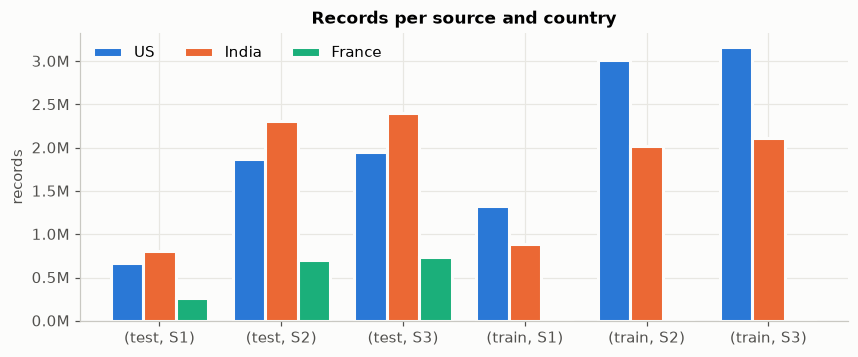

country    France    India       US
split src                          
test  S1   259452   809986   663106
      S2   703378  2312565  1871330
      S3   731615  2405000  1945701
train S1        0   883188  1323633
      S2        0  2017799  3016817
      S3        0  2115547  3170056

In [5]:
# Record counts per source and country
cnt = pd.concat([tr.assign(split="train"), te.assign(split="test")]) \
        .groupby(["split", "src", "country"]).size().unstack("country").fillna(0).astype(int)
ax = cnt[["US", "India", "France"]].plot.bar(color=[C["US"], C["India"], C["France"]], width=0.8,
                                             edgecolor="#fcfcfb", linewidth=2, figsize=(9, 3.4))
ax.set_title("Records per source and country"); ax.set_xlabel(""); ax.set_ylabel("records")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1e6:.1f}M"); ax.tick_params(axis="x", rotation=0)
ax.legend(title=None, ncols=3, loc="upper left"); plt.show()
cnt

## 2. Ground-truth structure

Things to notice:
- The typical S1 entity has **3–4 matches**; only **~5.6% are singletons** (no match).
- S2 and S3 each contain **several copies** of the same business (up to 5 and 6).
- **No S2/S3 record is matched to more than one S1** → a record can be assigned to at most one entity.
- **Matches never cross countries.**

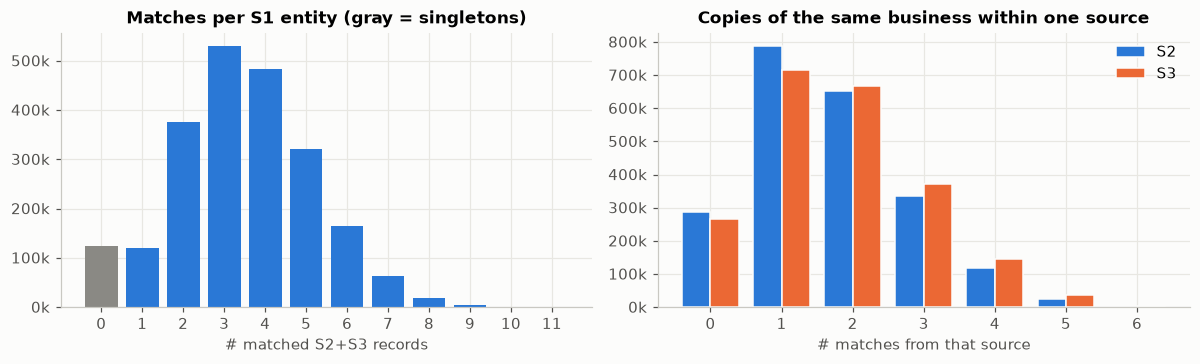

singletons: 5.58%   mean matches: 3.46
S2/S3 records matched to >1 S1: 0


cross-country true pairs: 0


S2 records with no S1 match (distractors): 26.6%


S3 records with no S1 match (distractors): 25.4%


In [6]:
n_match = pairs.groupby("s1").size().reindex(split.source1_entity_id).fillna(0).astype(int)
per_src = pairs.assign(src=pairs.m.str[:2]).groupby(["s1", "src"]).size().unstack(fill_value=0) \
               .reindex(split.source1_entity_id).fillna(0).astype(int)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
vc = n_match.value_counts().sort_index()
axs[0].bar(vc.index, vc.values, color=[GRAY if i == 0 else BLUE for i in vc.index], width=0.8)
axs[0].set_title("Matches per S1 entity (gray = singletons)"); axs[0].set_xlabel("# matched S2+S3 records")
axs[0].yaxis.set_major_formatter(lambda v, _: f"{v/1e3:.0f}k"); axs[0].set_xticks(vc.index)
w = 0.4
for j, (s, col) in enumerate([("S2", BLUE), ("S3", ORANGE)]):
    v = per_src[s].value_counts().sort_index()
    axs[1].bar(v.index + (j - 0.5) * w, v.values, width=w, color=col, label=s, edgecolor="#fcfcfb")
axs[1].set_title("Copies of the same business within one source"); axs[1].set_xlabel("# matches from that source")
axs[1].yaxis.set_major_formatter(lambda v, _: f"{v/1e3:.0f}k"); axs[1].legend()
plt.tight_layout(); plt.show()

m_counts = pairs.m.value_counts()
print(f"singletons: {(n_match==0).mean():.2%}   mean matches: {n_match.mean():.2f}")
print(f"S2/S3 records matched to >1 S1: {(m_counts>1).sum()}")
cc = tr.loc[pairs.s1, "country"].values != tr.loc[pairs.m, "country"].values
print(f"cross-country true pairs: {cc.sum()}")
for s in ("S2", "S3"):
    ids = tr.index[tr.src == s]
    print(f"{s} records with no S1 match (distractors): {1 - ids.isin(pairs.m).mean():.1%}")

**Why this matters for the metric.** F0.5 is computed *per S1 entity*, then averaged. For one entity:

$F_{0.5} = \dfrac{1.25\,P\,R}{0.25\,P + R}$

A singleton scores 1 if we predict nothing, 0 otherwise. Let's feel the precision/recall asymmetry:

In [7]:
from ber.io import f05_entity
truth = {"a", "b", "c", "d"}   # an entity with 4 true matches
for name, pred in [("perfect", truth), ("miss 2 (P=1, R=.5)", {"a", "b"}), ("1 extra wrong (P=.8, R=1)", truth | {"x"}),
                   ("2 extra wrong", truth | {"x", "y"}), ("predict nothing", set()), ("only 1 right", {"a"})]:
    print(f"{name:28s} F0.5 = {f05_entity(pred, truth):.3f}")
print("singleton, predict nothing  ->", f05_entity(set(), set()))
print("singleton, predict 1 wrong  ->", f05_entity({"x"}, set()))

perfect                      F0.5 = 1.000
miss 2 (P=1, R=.5)           F0.5 = 0.833
1 extra wrong (P=.8, R=1)    F0.5 = 0.833
2 extra wrong                F0.5 = 0.714
predict nothing              F0.5 = 0.000
only 1 right                 F0.5 = 0.625
singleton, predict nothing  -> 1.0
singleton, predict 1 wrong  -> 0.0


## 3. Noise catalogue

Rates (% of records) of each noise pattern, per split/source/country, measured on the **raw** text.
S1 is clean; S2 shouts in ALL-CAPS addresses; S3 writes US states in full and has alias markers ("X formerly Y").

In [8]:
prof = pd.DataFrame(json.load(open(RAW / "_noise_profile.json")))
prof["group"] = prof.split + " " + prof.src + " " + prof.country
cols = ["addr_empty", "name_all_upper", "addr_all_upper", "name_nonascii_latin", "name_junk_prefix", "name_brackets",
        "name_domain", "name_alias", "name_digit_in_word", "name_double_space", "addr_has_nonlatin",
        "addr_near", "addr_door", "addr_unit", "addr_lead_zero", "addr_cdp", "addr_us_zip5"]
prof.set_index("group")[cols].T.style.background_gradient(cmap="Blues", axis=None, vmin=0, vmax=30).format("{:.1f}")

group,train S1 India,train S1 US,train S2 India,train S2 US,train S3 India,train S3 US,test S1 France,test S1 India,test S1 US,test S2 France,test S2 India,test S2 US,test S3 France,test S3 India,test S3 US
addr_empty,0.0,0.0,2.9,3.7,3.1,3.5,0.0,0.0,0.0,3.0,2.2,2.9,2.9,2.4,2.8
name_all_upper,0.0,0.0,14.9,21.7,2.5,3.2,0.0,0.0,0.0,20.8,14.1,20.4,5.6,2.5,3.2
addr_all_upper,0.0,0.0,23.8,89.7,0.0,0.0,0.0,0.0,0.0,29.1,24.0,90.5,0.0,0.0,0.0
name_nonascii_latin,0.0,0.0,4.3,6.7,5.4,6.8,15.7,0.0,0.0,24.5,4.0,6.3,24.1,4.9,6.4
name_junk_prefix,0.0,0.2,1.4,2.1,1.5,2.1,0.1,0.0,0.1,0.6,1.3,1.9,0.6,1.4,1.9
name_brackets,5.1,0.0,9.6,6.5,10.2,6.5,8.0,5.2,0.0,10.1,9.4,6.2,10.0,10.0,6.4
name_domain,0.0,0.0,3.5,4.6,3.8,4.4,0.0,0.0,0.0,3.7,2.9,3.8,3.6,3.1,3.6
name_alias,0.0,0.0,0.0,0.0,1.8,2.7,0.0,0.0,0.0,0.0,0.0,0.0,1.5,1.5,2.2
name_digit_in_word,0.0,0.0,2.0,2.7,2.1,2.7,0.1,0.0,0.0,0.5,1.8,2.6,0.5,2.0,2.5
name_double_space,0.0,0.0,10.1,11.7,10.6,11.1,0.0,0.0,0.0,9.1,9.7,11.3,7.9,10.3,10.9


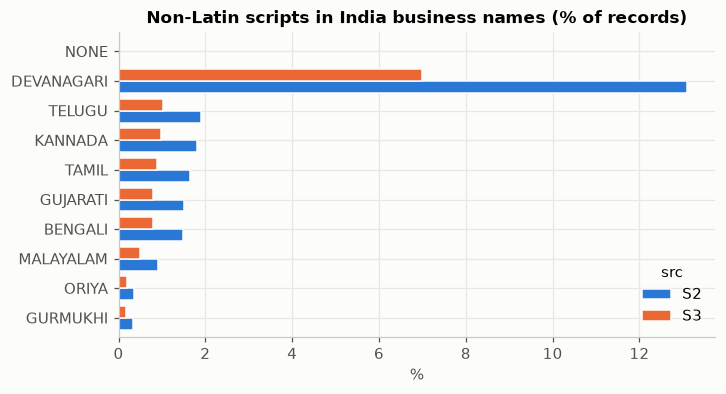

,business_name,name_norm
entity_id,,
S2-740714240,बॉम्बे प्रोड्यूसर प्राइवेट लिमिटेड,bombay producer private limited
S3-277345237,ఆదిత్య ఇండియన్ హాస్పిటాలిటీ సొల్యూషన్స్ ప్రైవేట్ లిమిటెడ్,aditya indian hospitality solutions private limited
S2-538003002,ಎಸ್ಎಸ್ ಸರ್ವಿಸಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,ss services private limited
S3-249178604,अर्बन मीडिया प्राइवेट लिमिटेड,urban media private limited
S2-808735751,രാം കൺസൾട്ടന്റ്സ് എൽഎൽപി,ram consultants llp
S3-787238123,राज प्रोडक्ट्स,raj products
S3-172020927,સન ઇન્વેસ્ટમેન્ટ પ્રાઇવેટ લિમિટેડ,sun investment private limited
S3-852948183,பாபா கன்சல்டன்சி,baba consultancy


In [9]:
# Script of the business name (India, S2 vs S3). Non-Latin names are phonetic transliterations.
ind = tr[(tr.country == "India") & tr.src.isin(["S2", "S3"])]
sc = ind.groupby("src").name_script.value_counts(normalize=True).mul(100).unstack(0).drop("LATIN").sort_values("S2")
ax = sc.plot.barh(color=[BLUE, ORANGE], width=0.8, figsize=(7, 3.6), edgecolor="#fcfcfb")
ax.set_title("Non-Latin scripts in India business names (% of records)"); ax.set_xlabel("%"); ax.set_ylabel("")
plt.show()
ind[ind.name_is_translit][["business_name", "name_norm"]].sample(8, random_state=1)

## 4. Preprocessing playground

`normalize_name` / `normalize_address` (in `src/ber/normalize.py`) produce these fields:

| field | meaning |
|---|---|
| `name_norm` | lowercased, accent-free, punctuation-free, OCR-fixed, alias-resolved, transliterated |
| `name_core` | `name_norm` minus legal forms and stopwords — the "identity" part |
| `name_legal` | canonical legal forms found (`inc`, `llc`, `pvt ltd`, `sarl`…) |
| `name_alias` / `name_domain` | the other half of "X dba Y", or the stem of a web domain |
| `addr_norm` | state removed, abbreviations canonicalized, null parts dropped, leading zeros stripped |
| `addr_state` | canonical state/region code (works for codes, full names, native scripts) |
| `addr_house` / `addr_numbers` | numeric tokens used as matching keys |

**Edit the strings below and re-run.**

In [10]:
names = ["Cabrera 5ecure Sciences LP", "Jaxaria Formerly Cabrera Secure Sciences", "emerakeystonecom",
         "Elite  + C0mpany", "Lawrence Venmfes Private (Limited)", "एसएस फूड प्राइवेट लिमिटेड",
         "ગોલ્ડ મીડિયા પ્રાઇવેટ લિમિટેડ", "Maison Àzar SASU", "-- Holloway Peak Inc Seafood"]
pd.DataFrame([{"raw": n, **normalize_name(n, RES)} for n in names]).drop(columns=["name_script"])

,raw,name_norm,name_core,name_legal,name_alias,name_domain,name_is_translit
0,Cabrera 5ecure Sciences LP,cabrera secure sciences lp,cabrera secure sciences,lp,,,False
1,Jaxaria Formerly Cabrera Secure Sciences,cabrera secure sciences,cabrera secure sciences,,jaxaria,,False
2,emerakeystonecom,emerakeystone,emerakeystone,,,emerakeystone,False
3,Elite + C0mpany,elite and company,elite,co,,,False
4,Lawrence Venmfes Private (Limited),lawrence venmfes private limited,lawrence venmfes,ltd pvt,,,False
5,एसएस फूड प्राइवेट लिमिटेड,ss food private limited,ss food,ltd pvt,,,True
6,ગોલ્ડ મીડિયા પ્રાઇવેટ લિમિટેડ,gold media private limited,gold media,ltd pvt,,,True
7,Maison Àzar SASU,maison azar sasu,maison azar,sasu,,,False
8,-- Holloway Peak Inc Seafood,holloway peak inc seafood,holloway peak seafood,inc,,,False


In [11]:
addrs = ["00709 Hackberry Saint, Tilden, Texas", "1344 MCDONALD HILL ROAD, CHILLICTHE CDP, OH",
         "165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky", "DL, North West, No C-956 Jd-36b, New Delhi",
         "Rajkot, Aqua, Flat B- 1002, New 150 Feet Ring Road, ગુજરાત", "N°23 R. D'arras, Lille, Nord", "NULL"]
pd.DataFrame([{"raw": a, **normalize_address(a, RES)} for a in addrs])

,raw,addr_norm,addr_state,addr_numbers,addr_postcode,addr_house,addr_has_native,addr_ncomp
0,"00709 Hackberry Saint, Tilden, Texas",709 hackberry st tilden,tx,709,,709,False,3
1,"1344 MCDONALD HILL ROAD, CHILLICTHE CDP, OH",1344 mcdonald hill rd chillicthe,oh,1344,,1344,False,3
2,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",165 barren river dr 2 erlanger,ky,165 2,,165,False,4
3,"DL, North West, No C-956 Jd-36b, New Delhi",n w c 956 jd 36b new delhi,dl,956 36b,,956,False,4
4,"Rajkot, Aqua, Flat B- 1002, New 150 Feet Ring Road, ગુજરાત",rajkot aqua b 1002 new 150 feet ring rd,gj,1002 150,,1002,True,5
5,"N°23 R. D'arras, Lille, Nord",ndeg23 r d arras lille,hdf,23,,23,False,3
6,NULL,,,,,,False,0


**How transliteration works.** Indic names are word-by-word *phonetic* spellings of English words
(`प्राइवेट` = "private"). We romanize with `unidecode` (→ `praaivett`), reduce to a consonant skeleton
(→ `prvt`), and look that up in a dictionary **learned from training pairs** (aligning native tokens with
the S1 name). Unknown words fall back to the romanization.

In [12]:
from unidecode import unidecode
for w in ["प्राइवेट", "लिमिटेड", "मार्केटिंग", "லிமிடெட்", "ലോജിസ്റ്റിക്സ്"]:
    rom = unidecode(w).lower(); sk = squash_phonetic(rom)
    print(f"{w:14s} unidecode={rom:18s} skeleton={sk:8s} -> {RES.native_token.get(sk, '(not in dictionary)')}")
print(f"\nlearned: {len(RES.native_token)} tokens, {len(RES.native_state)} native state names")
print(RES.native_state)

प्राइवेट       unidecode=praaivett          skeleton=prvt     -> private
लिमिटेड        unidecode=limittedd          skeleton=lmtd     -> limited
मार्केटिंग     unidecode=maarketting        skeleton=mrktng   -> marketing
லிமிடெட்       unidecode=limittett          skeleton=lmtt     -> limited
ലോജിസ്റ്റിക്സ് unidecode=loojisrrrriks      skeleton=ljsrks   -> logistics

learned: 428 tokens, 16 native state names
{'தமிழ்நாடு': 'in:tn', 'उत्तर प्रदेश': 'in:up', 'ಕರ್ನಾಟಕ': 'in:ka', 'हरियाणा': 'in:hr', 'महाराष्ट्र': 'in:mh', 'बिहार': 'in:br', 'ગુજરાત': 'in:gj', 'পশ্চিমবঙ্গ': 'in:wb', 'കേരളം': 'in:kl', 'राजस्थान': 'in:rj', 'ଓଡ଼ିଶା': 'in:od', 'తెలంగాణ': 'in:tg', 'दिल्ली': 'in:dl', 'मध्य प्रदेश': 'in:mp', 'ਪੰਜਾਬ': 'in:pb', 'ఆంధ్రప్రదేశ్': 'in:ap'}


## 5. Did cleaning help?

For a sample of **true pairs** and **random non-pairs from the same country**, compare the
token-set similarity (0–100) of raw vs. cleaned fields. We want the blue (true) mass pushed right and
separated from the orange (random) mass.

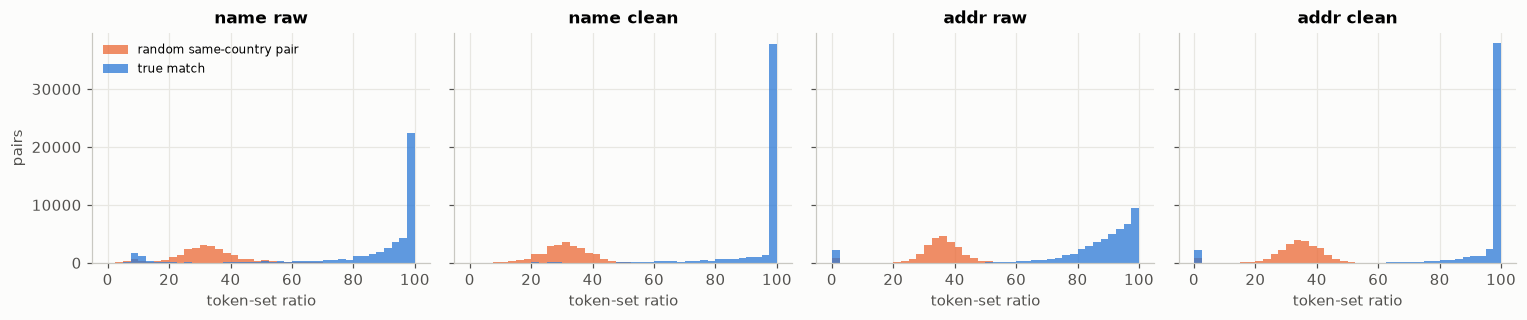

,true: mean,true: p10,random: mean
name raw,84.4,43.2,32.6
name clean,93.7,76.5,30.9
addr raw,85.1,70.1,35.2
addr clean,92.9,83.3,33.8


In [13]:
N = 50_000
sp = pairs.sample(N, random_state=0)
L, R = tr.loc[sp.s1], tr.loc[sp.m]
oth = tr[tr.src != "S1"]
negR = oth.sample(N, random_state=1)
keep = negR.country.values == L.country.values          # random partner from the same country
negL, negR = L[keep], negR[keep]

def sims(A, B):
    return pd.DataFrame({
        "name raw":    [fuzz.token_set_ratio(a.lower(), b.lower()) for a, b in zip(A.business_name, B.business_name)],
        "name clean":  [fuzz.token_set_ratio(a, b) for a, b in zip(A.name_core, B.name_core)],
        "addr raw":    [fuzz.token_set_ratio(a.lower(), b.lower()) for a, b in zip(A.business_address, B.business_address)],
        "addr clean":  [fuzz.token_set_ratio(a, b) for a, b in zip(A.addr_norm, B.addr_norm)],
    })
pos, neg = sims(L, R), sims(negL, negR)

fig, axs = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
bins = np.linspace(0, 100, 41)
for ax, c in zip(axs, pos.columns):
    ax.hist(neg[c], bins, color=ORANGE, alpha=.75, label="random same-country pair")
    ax.hist(pos[c], bins, color=BLUE, alpha=.75, label="true match")
    ax.set_title(c); ax.set_xlabel("token-set ratio")
axs[0].set_ylabel("pairs"); axs[0].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame({"true: mean": pos.mean(), "true: p10": pos.quantile(.1), "random: mean": neg.mean()}).round(1)

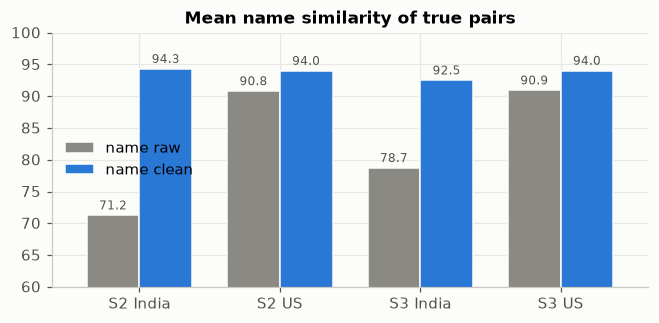

In [14]:
# Where did cleaning help most? True-pair name similarity by source x country, raw vs clean
g = pd.concat([pos, pd.DataFrame({"grp": sp.m.str[:2].values + " " + L.country.values})], axis=1)
ax = g.groupby("grp")[["name raw", "name clean"]].mean().plot.bar(color=[GRAY, BLUE], width=.75, figsize=(7, 3), edgecolor="#fcfcfb")
ax.set_ylim(60, 100); ax.set_title("Mean name similarity of true pairs"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
bar_labels(ax, "{:.1f}"); plt.show()

## 6. Where the difficulty is

Random non-pairs are easy (similarity ≈ 33). The hard cases are:

**(a) Name collisions.** Many *different* businesses share the same name. Half of all S1 entities share
their exact core name with another S1 entity. So the address has to break the tie.

S1 entities sharing core name with another S1: 49.4%


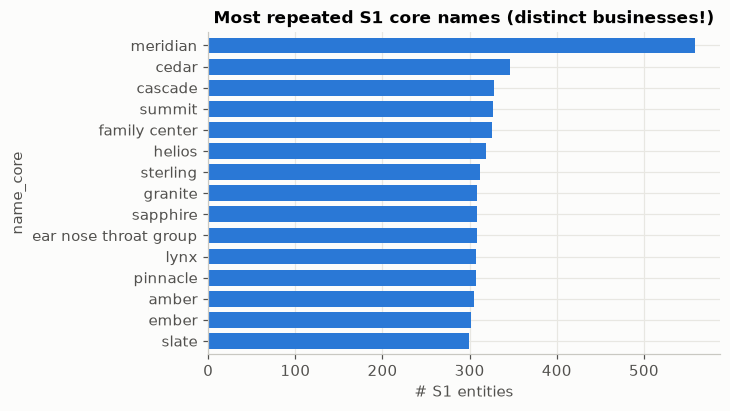

,business_name,business_address
entity_id,,
S1-19053820,Meridian,"4301 Laurel Oak Lane, Muncie, IN"
S1-484951417,Meridian Inc,"10809 Walnut Canyon Road, Albuquerque, NM"
S1-890148342,Meridian LLC,"VA, 1585 Bethel Church Road, Bedford County"
S1-412563527,Meridian LLC,"10 Montague Street, Brooklyn, NY"
S1-868926664,Meridian LLC,"246 Norland Knoll Drive, Frederick County, VA"
S1-983243647,Meridian LLC,"11432 141st Street, Fl 1, Scottsdale, AZ"
S1-864350602,Meridian,"Houston, TX, 1342 Dennis Street"
S1-515651979,Meridian LLC,"6653 Oakland Road, Loveland, OH"


In [15]:
s1 = tr[tr.src == "S1"]
vc = s1.name_core.value_counts()
print(f"S1 entities sharing core name with another S1: {(s1.name_core.map(vc) > 1).mean():.1%}")
ax = vc.head(15)[::-1].plot.barh(color=BLUE, figsize=(6, 3.8), width=.75)
ax.set_title("Most repeated S1 core names (distinct businesses!)"); ax.set_xlabel("# S1 entities"); plt.show()
s1[s1.name_core == "meridian"][["business_name", "business_address"]].head(8)

**(b) Distractors.** ~26% of S2/S3 records belong to *no* S1 entity, and many carry realistic
names that also appear in S1. The model must be willing to say "none of these".

**(c) Hard positives.** A few % of true matches have a completely different name (invented brand,
squashed domain) *or* an empty address. Use the slider values below to explore.

In [16]:
NAME_T, ADDR_T = 50, 50
lowN, lowA = pos["name clean"] < NAME_T, (pos["addr clean"] < ADDR_T) | (R.addr_norm.values == "")
tax = pd.Series({"both strong": (~lowN & ~lowA).mean(), "address-only (name weak)": (lowN & ~lowA).mean(),
                 "name-only (address weak/empty)": (~lowN & lowA).mean(), "both weak": (lowN & lowA).mean()}) * 100
print(tax.round(2).to_string())
ex = pd.DataFrame({"S1 name": L.business_name.values, "S1 addr": L.business_address.values,
                   "match name": R.business_name.values, "match addr": R.business_address.values})
print("\naddress-only examples:"); display(ex[(lowN & ~lowA).values].head(6))
print("name-only examples:");      display(ex[(~lowN & lowA).values].head(6))

both strong                       92.45
address-only (name weak)           3.03
name-only (address weak/empty)     4.49
both weak                          0.03

address-only examples:


,S1 name,S1 addr,match name,match addr
6,Future Enterprises Private Limited,"K.No 2702/1313, Opp Water, Tank, Danji Ki Hodi, Barmer, Rajasthan",Nylaorbiquo,"K.NO #2702/1313, OPP WATER, TANK, DANJI KI HODI, BARMER, Rajasthan"
9,Technologies Ampersand Agro Pvt Ltd,"Qtr No. 3, Type 4, P&T Qtr Pusa Road, Delhi, New Delhi, Delhi",Quoumbradelta,"Qtr No. 3, Type 4, P&T Qtr Pusa Road, Delhi, New Delhi, Delhi"
21,Arnett Entergy Inc.,"4669 3502, Wills Point, TX",Nylaquo,"004669 3502, Wills Point Township, Texas"
40,Radhu Welfare Society,"C/O-Mohammad Sharik Nazim, Vill- Rohua, Tola Rohua West Panch, Rohua East, Warisnagar,...",Miraarc,"C/o-omhammad Sharik Nazim, Warisnagar, BR"
61,Ram Care Pvt Ltd,"191, 5Th Main Road, 7Th Cross, Railway Layout, Bangalore South, Bangalore, Karnataka",Avikor,"191, 5Th Main Road, 7Th Cross, Railway Layout, Bangalore South, Bangalore, Karnataka"
125,"Kuenzi, Kristina, D.D.S.","765 Westwood Drive, Unit APT 102, Saint Louis, MO",#kuenzikristina,"00765 WESTWOOD DRIVE, SAINT LOUIS, MO"


name-only examples:


,S1 name,S1 addr,match name,match addr
42,Maines Mercator,"146 Fivefoot Prong Lane, Camden Wyoming, DE",Maines Mercator - 2061967355,
43,Golden Grand Harmony,"478 Springwood Drive, Mount Gilead, NC",Golden Grand,
87,AH India Private Limited,"17, Upadhyay Marg, Shujalpur Mandi, Madhya Pradesh",AH INDIA PRIVATE LTD,
107,Al Tirupati Infra Pvt Ltd,"S. No. 16/1/5 Wadgaon Bk., Padmavati Apts., Pune, Maharashtra",Al Tirupati Pvt Ltd Center,
120,"Rice Value Spring, Inc","79 Cross Road, Haverhill, MA","Rice Value Spring, Inc",
135,Tenezaca Institutions,"2939 Koring Road, Evansville, IN",TENEZACA INSTITUTIONS INC.,


## 7. Blocking, explained

### The problem
To find matches for one S1 entity we'd ideally compare it with **every** S2/S3 record. Let's count:

In [17]:
n_s1_test = (te.src == "S1").sum(); n_oth_test = (te.src != "S1").sum()
print(f"test: {n_s1_test:,} S1 x {n_oth_test:,} S2/S3 = {n_s1_test*n_oth_test:.2e} comparisons")
print(f"at 1 µs per comparison (optimistic for an ML model): {n_s1_test*n_oth_test/1e6/86400:,.0f} days")
print(f"true matches per S1 ≈ 3.5  ->  fraction of comparisons that matter: {3.5/n_oth_test:.1e}")

test: 1,732,544 S1 x 9,969,589 S2/S3 = 1.73e+13 comparisons
at 1 µs per comparison (optimistic for an ML model): 200 days
true matches per S1 ≈ 3.5  ->  fraction of comparisons that matter: 3.5e-07


That's impossible, and 99.99997% of those comparisons are obviously non-matches ("Cabrera Secure Sciences,
Kentucky" vs. "Ram Care Pvt Ltd, Bangalore").

### The idea
**Blocking = a cheap first stage that throws away obvious non-matches** so that the expensive matching
model only looks at a short list of plausible candidates per S1 entity.

```
10M S2/S3 records ──[ blocking: cheap, high-recall ]──> ~20-50 candidates per S1 ──[ ML matcher: expensive, precise ]──> final matches
```

The classic way: compute a **blocking key** for every record; only records with the **same key** are compared.
Records sharing a key form a **block**.

| key | idea | "Cabrera Secure Sciences, 165 Barren River Dr, Erlanger, KY" → key |
|---|---|---|
| exact core name | same normalized name | `US\|cabrera secure sciences` |
| first name token + state | same first word, same state | `US\|cabrera\|ky` |
| house no. + street word | same building | `US\|165\|barren` |

A blocking stage is judged by two numbers:
- **Pair recall** (a.k.a. *pair completeness*) = % of true matches that survive into the candidate set.
  **This caps your final recall** — a match dropped here can never be recovered.
- **Candidates per S1** (or *reduction ratio*) = how much work is left for the model. Fewer = faster, and
  also *easier* for the model (fewer look-alikes to confuse it).

Multiple keys are usually **unioned**: each catches matches the others miss.

### Worked example

In [18]:
first_tok = lambda s: s.str.split().str[0].fillna("")
KEYS = {
    "exact core name":          lambda d: d.country + "|" + d.name_core,
    "first name token + state": lambda d: d.country + "|" + first_tok(d.name_core) + "|" + d.addr_state,
    "house no. + street word":  lambda d: d.country + "|" + d.addr_house + "|" + d.addr_norm.str.split().str[1].fillna(""),
}
t0 = time.time()
oth = tr[tr.src != "S1"]
oth_keys = pd.DataFrame({k: f(oth) for k, f in KEYS.items()}, index=oth.index)
print(f"computed keys for {len(oth):,} records in {time.time()-t0:.0f}s")

def explain_blocking(s1_id, show=6):
    rec = tr.loc[[s1_id]]
    truth = set(pairs.loc[pairs.s1 == s1_id, "m"])
    print(f"S1: {rec.business_name.iloc[0]!r} | {rec.business_address.iloc[0]!r}   true matches: {len(truth)}\n")
    union = set()
    for k, f in KEYS.items():
        key = f(rec).iloc[0]
        if key.endswith("|"):
            print(f"[{k}] key={key!r} -> empty key, block skipped"); continue
        block = oth_keys.index[oth_keys[k].values == key]
        hit = truth & set(block); union |= set(block)
        print(f"[{k}] key={key!r}\n    block size={len(block):,}   true matches caught={len(hit)}/{len(truth)}")
        sel = list(hit) + [x for x in block[:show + len(hit)] if x not in hit][:max(0, show - len(hit))]
        display(oth.loc[sel, ["business_name", "business_address"]].assign(is_match=lambda d: d.index.isin(truth)))
    print(f"UNION: {len(union):,} candidates, recall {len(truth & union)}/{len(truth)}")
    missed = truth - union
    if missed:
        print("missed by every key:"); display(tr.loc[list(missed), ["business_name", "business_address", "name_core", "addr_norm"]])

explain_blocking("S1-706225498")

computed keys for 10,320,219 records in 62s
S1: 'Cabrera Secure Sciences' | '165 Barren River Drive, Unit UNIT 2, Erlanger, KY'   true matches: 7

[exact core name] key='US|cabrera secure sciences'
    block size=7   true matches caught=7/7


,business_name,business_address,is_match
entity_id,,,
S3-334188010,Jaxaria Formerly Cabrera Secure Sciences,"165 Barren River Drive, Unit UNIT 2, Erlanger, KY",True
S2-103340592,Cabrera 5ecure Sciences LP,"165 BARREN RIVER DR, ERLANGER KY, KY",True
S2-467560300,Cabrera Secure Sciences Ltd,"BARREN RIVER DR, ERLANGER, KY",True
S2-906818544,CABRERA SECURE SCIENCES,"ERLANGER, KY, 165 BARREN RIVER DRIVE",True
S3-285657516,Cabrera Secure Sciences,"Kentucky, Unit UNIT 2, Barren River Dr, Erlanger Ky",True
S3-382584258,Cabrera Secure Sciences,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True
S3-291610031,Cabrera Secure Sciences | www.cabreras.com,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True


[first name token + state] key='US|cabrera|ky'
    block size=23   true matches caught=7/7


,business_name,business_address,is_match
entity_id,,,
S3-334188010,Jaxaria Formerly Cabrera Secure Sciences,"165 Barren River Drive, Unit UNIT 2, Erlanger, KY",True
S2-103340592,Cabrera 5ecure Sciences LP,"165 BARREN RIVER DR, ERLANGER KY, KY",True
S2-467560300,Cabrera Secure Sciences Ltd,"BARREN RIVER DR, ERLANGER, KY",True
S2-906818544,CABRERA SECURE SCIENCES,"ERLANGER, KY, 165 BARREN RIVER DRIVE",True
S3-285657516,Cabrera Secure Sciences,"Kentucky, Unit UNIT 2, Barren River Dr, Erlanger Ky",True
S3-382584258,Cabrera Secure Sciences,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True
S3-291610031,Cabrera Secure Sciences | www.cabreras.com,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True


[house no. + street word] key='US|165|barren'
    block size=4   true matches caught=4/7


,business_name,business_address,is_match
entity_id,,,
S3-334188010,Jaxaria Formerly Cabrera Secure Sciences,"165 Barren River Drive, Unit UNIT 2, Erlanger, KY",True
S2-103340592,Cabrera 5ecure Sciences LP,"165 BARREN RIVER DR, ERLANGER KY, KY",True
S3-382584258,Cabrera Secure Sciences,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True
S3-291610031,Cabrera Secure Sciences | www.cabreras.com,"165 Barren River Drive, # UNIT 2, Erlanger Ky, Kentucky",True


UNION: 23 candidates, recall 7/7


Read the output above: each key catches a *different* subset of the true matches, and some blocks contain
look-alikes that aren't matches (e.g. same street number, different business). That's fine — blocking only
has to *keep* true matches; the matcher later rejects the look-alikes.

Now a case where name blocking is dangerous — a **very common name**. The "exact name" block for a
"Meridian" business contains hundreds of different Meridians across the country:

In [19]:
mer = s1[(s1.name_core == "meridian") & s1.index.isin(pairs.s1)].index[0]
explain_blocking(mer, show=8)

S1: 'Meridian' | '4301 Laurel Oak Lane, Muncie, IN'   true matches: 5

[exact core name] key='US|meridian'
    block size=1,637   true matches caught=3/5


,business_name,business_address,is_match
entity_id,,,
S2-51046564,Meridian,"301 LAUREL OAK LN, MUNCIE, IN",True
S2-18402374,MERIDIAN,"301 LAUREL OAK LN, MUNCIE, IN",True
S2-407867497,Meridian,"301 LAUREL OAK LANE, PMB 6355, MUNCIE, IN",True
S2-899773860,*** Meridian LLC,"5969 86, WILMINGTON, NY",False
S2-517140140,Meridian Llc,"2605 KENNEDY LN, TEXARKANA, TX",False
S2-493730592,Meridian C0rp,"14 BEACON AVE, VINEARD HAVEN, MA",False
S2-557152251,Meridian Llc,"11042 WOODRING DR, MATHER, CA",False
S2-883194048,MERIDIAN LLC,"2434 KENSINGTON AVE, SALT LAKE CITY, UT",False


[first name token + state] key='US|meridian|in'
    block size=113   true matches caught=5/5


,business_name,business_address,is_match
entity_id,,,
S2-407867497,Meridian,"301 LAUREL OAK LANE, PMB 6355, MUNCIE, IN",True
S2-51046564,Meridian,"301 LAUREL OAK LN, MUNCIE, IN",True
S2-18402374,MERIDIAN,"301 LAUREL OAK LN, MUNCIE, IN",True
S2-318655509,Meridian-Services,"LAUREL OAK LANE, MUNCIE, IN",True
S3-717121550,Meridian Center,"4301 Laurel Oak Lane, Muncie, Indiana",True
S2-121052016,Meridian (Tn),"62430 LOCUST RD, PO BOX 3477, SOUH BEND, IN",False
S2-719068510,MERIDIAN [SEA],"6660. 550, DECATUR, IN",False
S2-995659111,MERIDIAN FAMILY FAMILY PRACTICE LLC,"11544-B HORSESHOE BEND ROAD, BROOKSTON, IN",False


[house no. + street word] key='US|4301|laurel'
    block size=1   true matches caught=1/5


,business_name,business_address,is_match
entity_id,,,
S3-717121550,Meridian Center,"4301 Laurel Oak Lane, Muncie, Indiana",True


UNION: 1,696 candidates, recall 5/5


### Recall vs. cost across the validation fold
Numbers from `reports/eda_stats.json` (computed by `python -m ber.analysis` on all 220k validation S1 entities;
blocks with >2000 records were skipped to keep it tractable).

,pair_recall_pct,cands_per_s1
name_core_exact,59.27,58.2
name_first_tok+state,75.40,292.5
name_first_tok,42.55,139.6
house+first_street_tok,48.69,73.4
UNION,91.16,536.0


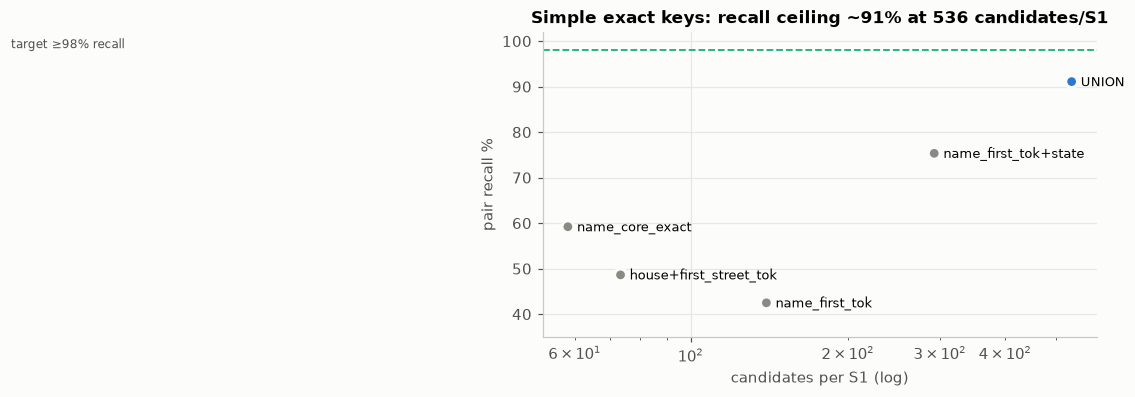

In [20]:
st = json.load(open(ROOT / "reports/eda_stats.json"))
b = pd.DataFrame(st["blocking_key_recall_val"]).T[["pair_recall_pct", "cands_per_s1"]].astype(float)
display(b)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.scatter(b.cands_per_s1, b.pair_recall_pct, s=60, color=[GRAY]*4 + [BLUE], zorder=3, edgecolor="#fcfcfb", linewidth=2)
for k, r in b.iterrows():
    ax.annotate(k, (r.cands_per_s1, r.pair_recall_pct), xytext=(6, -3), textcoords="offset points", fontsize=8.5)
ax.axhline(98, color=AQUA, lw=1.2, ls="--"); ax.text(5, 98.5, "target ≥98% recall", color="#52514e", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("candidates per S1 (log)"); ax.set_ylabel("pair recall %")
ax.set_title("Simple exact keys: recall ceiling ~91% at 536 candidates/S1"); ax.set_ylim(35, 102); plt.show()

**Why exact keys fall short here:** a single typo (`Cabrera 5ecure` fixed, but `Venmfes` isn't), a swapped
word, an invented brand name, or an empty address changes the key → the true match lands in a different block.
Meanwhile common names/streets make huge blocks. We need **fuzzy** blocking.

## 8. A better blocker: TF-IDF nearest neighbours (demo on one state)

Instead of "same key or nothing", represent each record as a vector of **character 3-grams** weighted by
TF-IDF (rare n-grams like `bre`,`cab` count more than `inc`, `ser`), and retrieve the **top-k most similar**
records by cosine similarity. A typo only changes a few n-grams, so similarity stays high.

We do this separately for the **name** and the **address**, and also a **combined** score (average of the two).
To keep it fast in a notebook we restrict to one US state (records whose state is missing are therefore
excluded here — a real pipeline also searches those).

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

STATE, COUNTRY = "ky", "US"           # try "oh", "me", or an Indian code like "ka" with COUNTRY="India"
val_ids = set(split.source1_entity_id[split.fold == "val"])
Q = s1[(s1.country == COUNTRY) & (s1.addr_state == STATE) & s1.index.isin(val_ids)]
D = oth[(oth.country == COUNTRY) & (oth.addr_state == STATE)]
truth_pairs = pairs[pairs.s1.isin(Q.index)]
print(f"queries (val S1): {len(Q):,}   searchable S2/S3: {len(D):,}   true pairs: {len(truth_pairs):,}")
print(f"true pairs whose record is outside this state block (state missing/different): "
      f"{(~truth_pairs.m.isin(D.index)).mean():.1%}")

def tfidf(field):
    v = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 3), min_df=2, sublinear_tf=True, dtype=np.float32)
    v.fit(pd.concat([Q[field], D[field]]))
    return v.transform(Q[field]), v.transform(D[field])

t0 = time.time()
qn, dn = tfidf("name_norm"); qa, da = tfidf("addr_norm")
print(f"vectorized in {time.time()-t0:.1f}s; name vocab {qn.shape[1]:,}, addr vocab {qa.shape[1]:,}")

queries (val S1): 2,985   searchable S2/S3: 132,755   true pairs: 10,156
true pairs whose record is outside this state block (state missing/different): 4.5%


vectorized in 6.6s; name vocab 11,366, addr vocab 8,158


retrieval done in 21.8s


,name only,address only,name + address
k (candidates per S1),,,
1,23.85,24.72,26.45
2,42.98,45.83,49.27
3,57.61,61.98,67.16
5,73.84,79.61,88.07
10,82.40,89.26,95.09
20,85.69,93.09,95.30
30,87.11,94.06,95.37
50,88.54,94.62,95.43


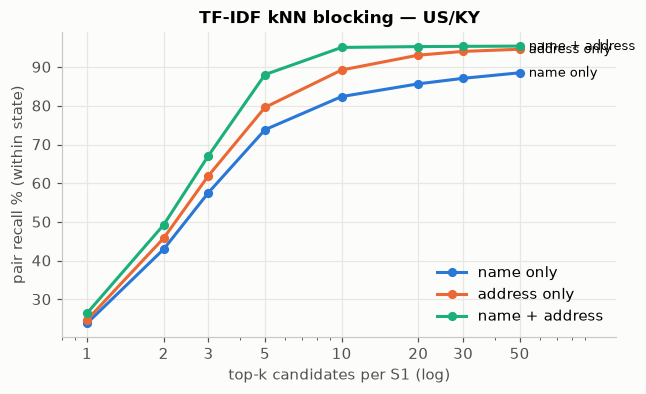

In [22]:
KMAX = 50
def topk(sim_fn, k=KMAX, chunk=1000):
    out = np.empty((len(Q), k), dtype=np.int64)
    for i in range(0, len(Q), chunk):
        S = sim_fn(slice(i, i + chunk))
        S = S.toarray() if sparse.issparse(S) else S
        idx = np.argpartition(-S, k, axis=1)[:, :k]
        order = np.take_along_axis(S, idx, 1).argsort(axis=1)[:, ::-1]
        out[i:i + chunk] = np.take_along_axis(idx, order, 1)
    return out

t0 = time.time()
nn = {
    "name only":      topk(lambda s: qn[s] @ dn.T),
    "address only":   topk(lambda s: qa[s] @ da.T),
    "name + address": topk(lambda s: (qn[s] @ dn.T + qa[s] @ da.T) * 0.5),
}
print(f"retrieval done in {time.time()-t0:.1f}s")

qpos = {q: i for i, q in enumerate(Q.index)}
t_q = truth_pairs.s1.map(qpos).values; t_m = truth_pairs.m.values
D_ids = D.index.values
ks = [1, 2, 3, 5, 10, 20, 30, 50]
rec = {}
for name, I in nn.items():
    cand_ids = D_ids[I]                                   # (n_queries, KMAX)
    rank = np.full(len(t_q), 10**9)
    for j in range(KMAX):
        hit = (cand_ids[t_q, j] == t_m) & (rank == 10**9)
        rank[hit] = j + 1
    rec[name] = [100 * (rank <= k).mean() for k in ks]
rec = pd.DataFrame(rec, index=pd.Index(ks, name="k (candidates per S1)")).round(2)
display(rec)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for (name, col) in zip(rec.columns, [BLUE, ORANGE, AQUA]):
    ax.plot(rec.index, rec[name], marker="o", ms=5, lw=2, color=col, label=name)
    ax.annotate(name, (rec.index[-1], rec[name].iloc[-1]), xytext=(6, 0), textcoords="offset points", fontsize=8.5, va="center")
ax.set_xscale("log"); ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("top-k candidates per S1 (log)"); ax.set_ylabel("pair recall % (within state)")
ax.set_title(f"TF-IDF kNN blocking — {COUNTRY}/{STATE.upper()}"); ax.set_xlim(0.8, 120); ax.legend(loc="lower right"); plt.show()

Compare with the exact-key union (~91% recall at **536** candidates): fuzzy retrieval on name+address should
reach the high 90s with only **tens** of candidates. The final pipeline will combine several retrievers
(name kNN, address kNN, combined kNN, maybe a multilingual embedding model) **per source** (top-k from S2 and
top-k from S3 separately, since an entity has up to 5–6 copies in each) plus cheap exact keys, and take the union.

Let's inspect what the retriever returns for one query — the matcher's job is to pick the true ones out of this list:

In [23]:
qi = 7                                        # change me
I = nn["name + address"]
q = Q.iloc[qi]; truth = set(pairs.loc[pairs.s1 == Q.index[qi], "m"])
print(f"QUERY: {q.business_name!r} | {q.business_address!r}   ({len(truth)} true matches)")
cand = D.iloc[I[qi, :15]][["src", "business_name", "business_address"]].copy()
cand["score"] = ((qn[qi] @ dn[I[qi, :15]].T + qa[qi] @ da[I[qi, :15]].T) * 0.5).toarray().ravel().round(3)
cand["TRUE MATCH"] = cand.index.isin(truth)
cand

QUERY: 'N & I Teucrium, LLC' | 'Paintsville, KY, 1119 Boyd Street'   (0 true matches)


,src,business_name,business_address,score,TRUE MATCH
entity_id,,,,,
S2-20499168,S2,"N & Í Teucrium West, LLC","1140 1/2 BOYD ST, PAINTSVILLE, KY",0.860,False
S2-297495058,S2,"N & I Teucrium, Holdings","1140 1/2 BOYD STREET, PAINTSVILLE, KY",0.831,False
S3-636873996,S3,Preferred LLC Téucrium Téucrium,"2006 Grasmere Dr, Loiusville CDP, Kentucky",0.415,False
S2-657086901,S2,O/K Téucrium,"1 CAMPGROUND ROAD, MAMMOTH CAVE, KY",0.388,False
S3-422745398,S3,Novola Téucrium,"110 Park Rd, Paducah, Kentucky",0.381,False
S3-869622074,S3,Ament Téucrium,"17 Sadye Court, # Apartment 1, Fort Thomas Ky, Kentucky",0.378,False
S3-399584331,S3,"Nader Teucrium,","95- Broadford Rd, Falmouuth, Kentucky",0.372,False
S3-387944295,S3,Nader Téucrium,"95- Broadford Rd, Falmouuth, Kentucky",0.372,False
S2-129056733,S2,Nexant Teucrium,"855 LOUISVILLE ROAD, FRANKFORT, KY",0.371,False


## 9. France — the unseen test country

No France labels exist. The pipeline must treat `country` as an open label. What changes:
different legal forms (SARL, SAS, EURL…), French street words (RUE/R, AV, BD), departments instead of
regions in S2/S3, and very generic vocabulary (club, école, amicale).

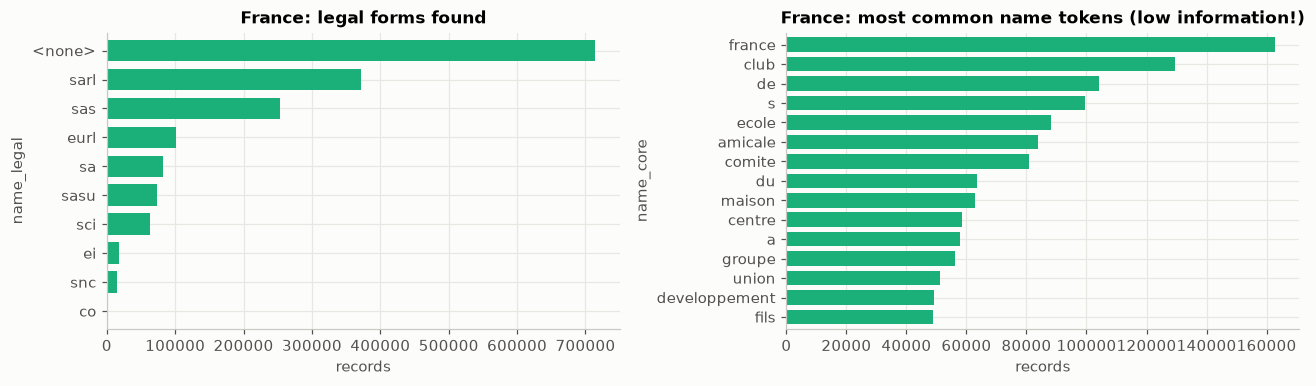

,src,business_name,business_address,name_norm,addr_norm,addr_state
entity_id,,,,,,
S2-82198660,S2,Lycée de la Prirfre,"46 R HENRI CARRITTE, ROUBAIX, Hauts-de-France",lycee de la prirfre,46 r henri carritte roubaix,hdf
S2-873042910,S2,Amicale du Art SARL,"47 RUE LACORNEE, BORDEAUX, Gironde",amicale du art sarl,47 r lacornee bordeaux,naq
S2-389546873,S2,Brixnoviyuma,"131 RUE DU BOIS HARDY, Nantes",brixnoviyuma,131 r du bois hardy nantes,
S3-908966237,S3,Halte Centre Sarl,"221 Boulevard De Fourmies, Roubaix",halte centre sarl,221 blvd de fourmies roubaix,
S2-723162819,S2,Etang Parents,"9 R DOTTAWA, Loire-Atlantique, NANTES",etang parents,9 r dottawa nantes,pdl
S2-364370666,S2,Clinique du Màrtin SA,"33 D ALLEE DU MOULIN, LA TESTE-DE-BUCH, Nouvelle-Aquitaine",clinique du martin sa,33 d all du moulin la teste de buch,naq
S2-415402199,S2,LOCEAN EMILE LYCÉE DISTRIBUTION,"185 AVENUE DE BRETAGNE, LILLE, Hauts-de-France",locean emile lycee distribution,185 ave de bretagne lille,hdf
S2-65033398,S2,Mam Gèstion SARL,"34 BIS R. DE SAINT-OMER, LILLE, Nord",mam gestion sarl,34 bis r de st omer lille,hdf
S3-739172766,S3,PESSAC AMICALE SASU,"16 Bis Rue Du Merle, Pessac, Nouvelle-Aquitaine",pessac amicale sasu,16 bis r du merle pessac,naq


In [24]:
fr = te[te.country == "France"]
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
fr.name_legal.replace("", "<none>").value_counts().head(10)[::-1].plot.barh(ax=axs[0], color=AQUA, width=.75)
axs[0].set_title("France: legal forms found"); axs[0].set_xlabel("records")
fr.name_core.str.split().explode().value_counts().head(15)[::-1].plot.barh(ax=axs[1], color=AQUA, width=.75)
axs[1].set_title("France: most common name tokens (low information!)"); axs[1].set_xlabel("records")
plt.tight_layout(); plt.show()
fr.sample(10, random_state=0)[["src", "business_name", "business_address", "name_norm", "addr_norm", "addr_state"]]

In [25]:
# Profile comparison: are cleaned fields populated similarly in France vs. the training countries?
tp = pd.DataFrame(st["train_country_profile"]).assign(split="train")
sp_ = pd.DataFrame(st["test_country_profile"]).assign(split="test")
pd.concat([tp, sp_]).set_index(["split", "src", "country"]).drop(columns="n")

addr_empty_pct  state_found_pct  legal_found_pct  alias_pct
split src country                                                             
train S1  India              0.00           100.00            84.29       0.00
          US                 0.00           100.00            53.61       0.00
      S2  India              2.87            97.13            78.55       0.00
          US                 3.68            96.32            47.63       0.00
      S3  India              3.07            96.93            75.76       2.06
          US                 3.50            96.50            46.94       3.26
test  S1  France             0.00           100.00            68.92       0.00
          India              0.00           100.00            84.26       0.00
          US                 0.00           100.00            53.60       0.00
      S2  France             3.06            64.24            56.26       0.00
          India              2.28            97.72            79.82       0.00
          US                 2.94            97.06            49.64       0.00
      S3  France             2.94            65.92            55.40       1.76
          India              2.46            97.54            77.50       1.65
          US                 2.84            97.16            49.03       2.65

## Takeaways

- **Clean first**: normalization lifts true-pair name similarity from ~85 to ~93 (India S2: 71 → 94).
- **Constraints to exploit**: same-country only; each S2/S3 record → at most one S1.
- **Name alone is not enough** (collisions) → address and context features decide.
- **Blocking**: exact keys cap recall at ~91%; fuzzy TF-IDF / embedding kNN, per source, unioned → target ≥98% at ≤50 candidates.
- **France**: rely on country-agnostic features; watch calibration.

Next notebook: candidate generation at full scale + pairwise matcher.